In [48]:
# Import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import io
from PIL import Image
import glob
import os
import pandas as pd
import matplotlib
import re
import seaborn as sns
import sys
from datetime import datetime, timedelta
sys.path.append('C:/Seafile/BSc_code/')
from functions import *
import h5py
import pingouin as pg
from scipy.stats import ttest_ind, mannwhitneyu
from scipy.stats import linregress

In [2]:
# Main processing loop for multiple files
pc = 'sophia'
if pc == 'sophia':
    basevol='C:/Seafile/'
    basepath = basevol + '/BSc_data/'
    data_info = basepath + '/data_info/'
    output_folder = basepath + "/processed_data/"
    npz_directory = basepath + 'shark_tracking_data/'
    figures_path = basepath + "figures/"
    mat_file_path = basepath + 'carangids_manual_tracking/tracking/'
else:
    basevol = '/Users/ang/Seafile/'
    basepath = basevol + '/BSc_data/'
    data_info = basepath + '/data_info/'
    output_folder = basepath + "/processed_data/"
    npz_directory = basepath + 'shark_tracking_data/'
    figures_path = basepath + "figures/"
    mat_file_path = basepath + 'carangids_manual_tracking/tracking/'

In [51]:
df = pd.read_hdf(output_folder + "final_sharks.h5", key='sharks')
df.head()

,index,SPEED#wcentroid,ID,X#pcentroid,Y#pcentroid,ANGLE,frame,time,headx,heady,...,normalized_nnd,mean_body_length,body_length,standardized_speed,tailbeat_frequency,tailbeat_amplitude,standardized_amplitude,strouhal_number,Trial_num,events
0,0,0.000000,0,NaN,NaN,-0.263183,0,0.00,2044.00,685.000000,...,0.754182,168.769768,177.037783,NaN,1.020408,73.417593,0.414700,NaN,0,0
1,1,55.754349,0,NaN,NaN,-0.253584,1,0.01,2045.00,685.000000,...,0.751215,168.968342,177.447051,NaN,1.020408,73.417593,0.413744,NaN,0,0
2,2,103.976613,0,NaN,NaN,-0.245468,2,0.02,2046.00,684.333333,...,0.751158,168.964560,177.425603,NaN,1.020408,73.417593,0.413794,NaN,0,0
3,3,123.176350,0,NaN,NaN,-0.238684,3,0.03,2047.75,684.000000,...,0.747436,169.092242,177.486965,NaN,1.020408,73.417593,0.413651,NaN,0,0
4,4,126.865948,0,NaN,NaN,-0.233522,4,0.04,2049.20,683.800000,...,0.743690,169.239818,176.966319,NaN,1.020408,73.417593,0.414868,NaN,0,0


### Counts


Value Counts (Normalized):
 unique_id_count
1.0    0.368733
2.0    0.201609
3.0    0.184312
4.0    0.215275
5.0    0.010982
6.0    0.019089
Name: proportion, dtype: float64

Sum of proportions: 1.0


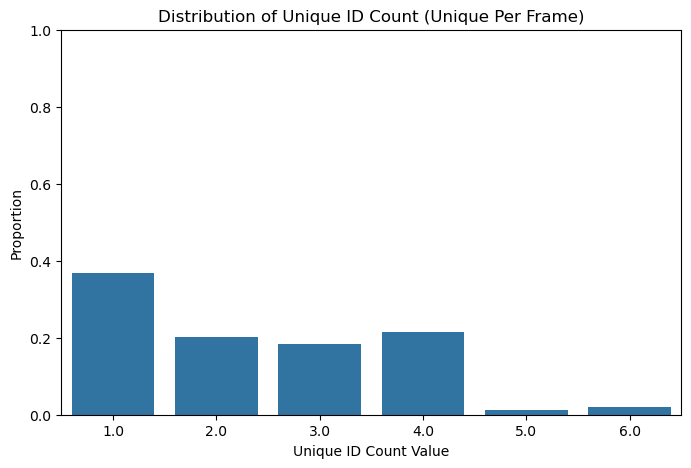

In [52]:
# Drop duplicates based on (frame, unique_id_count)
df_unique = df.drop_duplicates(subset=['frame', 'unique_id_count'])

# Count occurrences of each unique_id_count
count_series = df_unique['unique_id_count'].value_counts(normalize=True).sort_index()

# ✅ Validation Step
print("\nValue Counts (Normalized):\n", count_series)
print("\nSum of proportions:", count_series.sum())  # Should be 1.0

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=count_series.index, y=count_series.values)

# Labels
plt.xlabel("Unique ID Count Value")
plt.ylabel("Proportion")
plt.title("Distribution of Unique ID Count (Unique Per Frame)")
plt.ylim(0, 1)  # Ensure the y-axis goes from 0 to 1

plt.show()

Carangids Value Counts (Normalized):
 carangids
0    0.894063
1    0.105937
Name: proportion, dtype: float64

Sum of proportions: 1.0


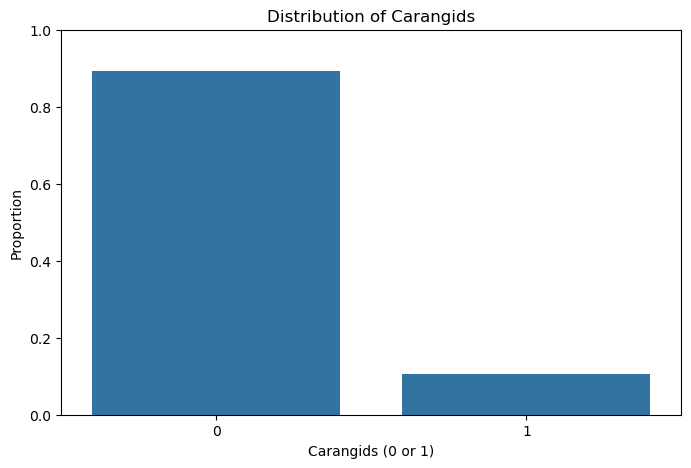

In [53]:
# Count occurrences of each carangids value
count_series = df['carangids'].value_counts(normalize=True).sort_index()

# ✅ Validation Step
print("Carangids Value Counts (Normalized):\n", count_series)
print("\nSum of proportions:", count_series.sum())  # Should be 1.0

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=count_series.index, y=count_series.values)

# Labels
plt.xlabel("Carangids (0 or 1)")
plt.ylabel("Proportion")
plt.title("Distribution of Carangids")
plt.ylim(0, 1)  # Ensure the y-axis goes from 0 to 1

plt.show()


Value Counts (Excluding events = 0):
 events
c      22
c+s    10
s      12
Name: count, dtype: int64

Sum of counts: 44


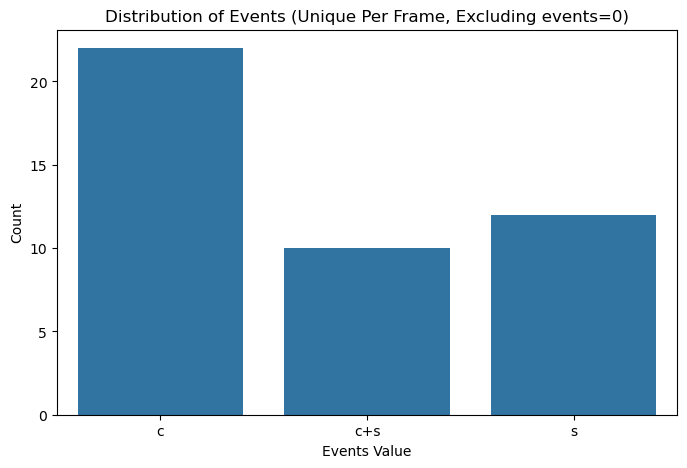

In [59]:
# Drop duplicates based on (frame, events)
df_unique = df[df['events'] != 0].drop_duplicates(subset=['frame', 'events'])

# Count occurrences of each unique 'events' (no normalization)
count_series = df_unique['events'].value_counts().sort_index()

# ✅ Validation Step
print("\nValue Counts (Excluding events = 0):\n", count_series)
print("\nSum of counts:", count_series.sum())  # Just for validation

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x=count_series.index, y=count_series.values)

# Labels
plt.xlabel("Events Value")
plt.ylabel("Count")
plt.title("Distribution of Events (Unique Per Frame, Excluding events=0)")

plt.show()


### Histogramme

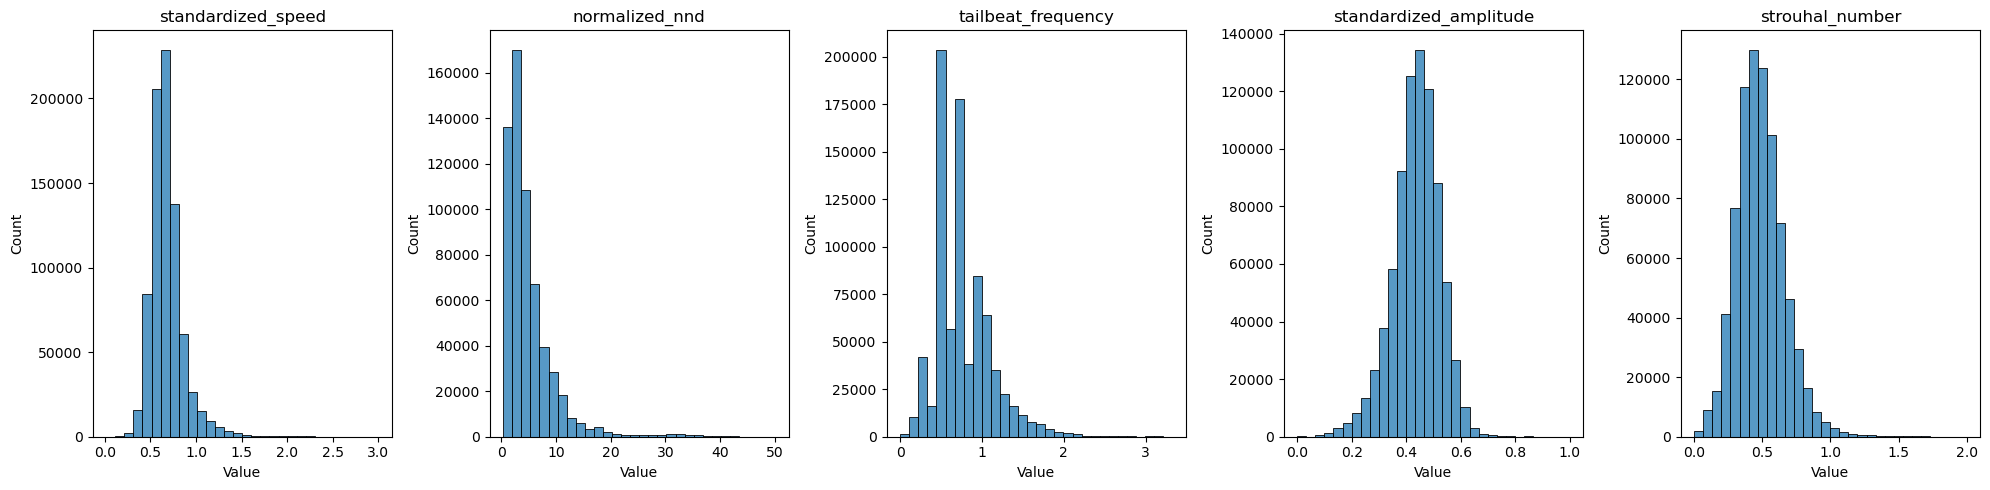

In [54]:
metrics = ['standardized_speed', 'normalized_nnd', 'tailbeat_frequency', 
           'standardized_amplitude', 'strouhal_number']

# Apply filtering: Only keep values < 2 for the specified metrics
df_filtered = df.copy()
df_filtered['standardized_amplitude'] = df_filtered['standardized_amplitude'][df_filtered['standardized_amplitude'] < 1]
df_filtered['strouhal_number'] = df_filtered['strouhal_number'][df_filtered['strouhal_number'] < 2]
df_filtered['standardized_speed'] = df_filtered['standardized_speed'][df_filtered['standardized_speed'] < 3]

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=len(metrics), figsize=(20, 5))

# Loop through metrics and plot count-based histograms
for i, metric in enumerate(metrics):
    sns.histplot(df_filtered[metric].dropna(), bins=30, kde=False, stat="count", ax=axes[i])  # Drop NaN values
    axes[i].set_title(metric)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()


### Speed vs. Metrics

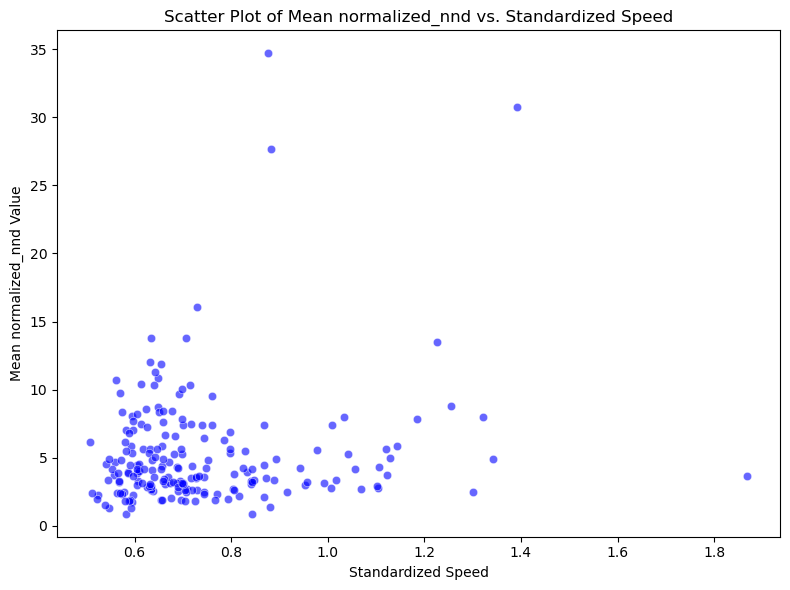

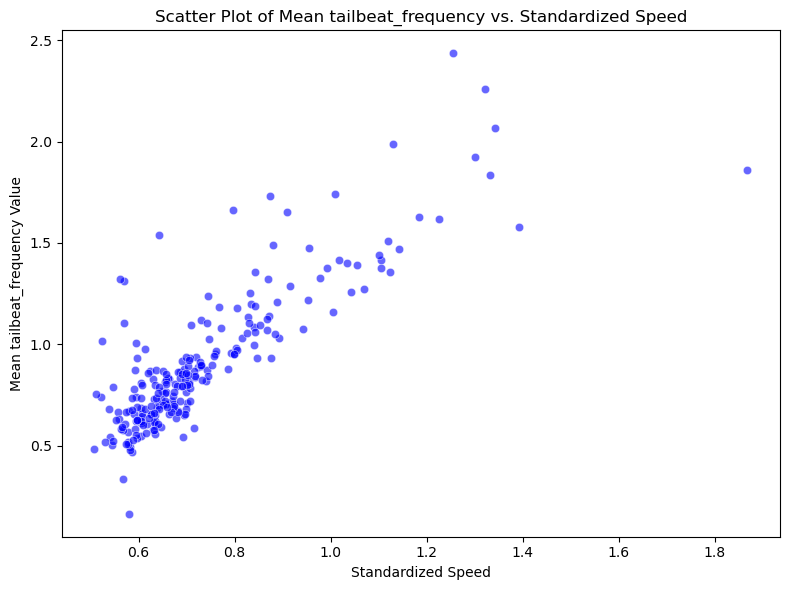

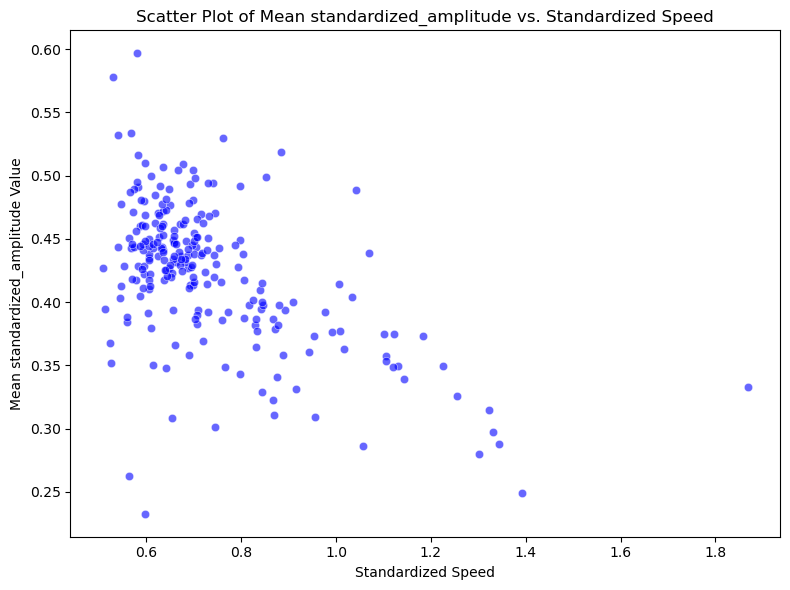

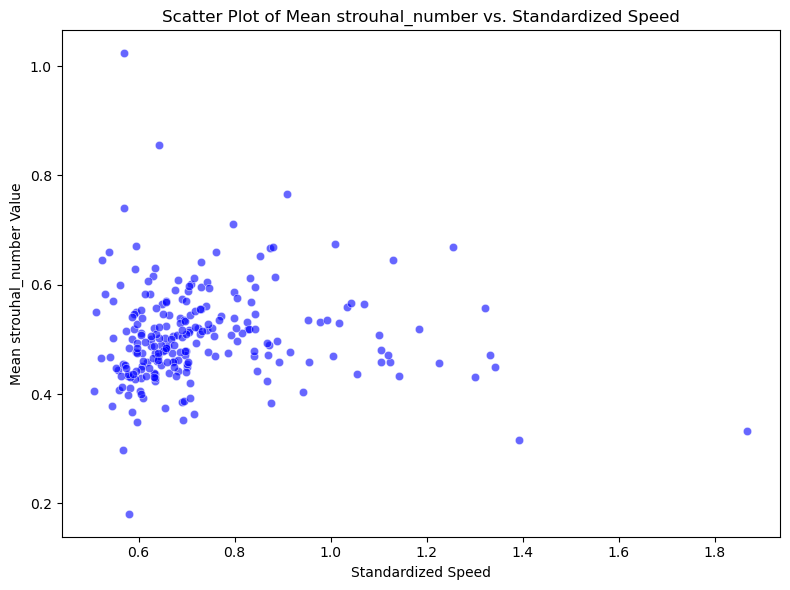

In [50]:
# Define the list of metrics you want to plot
metrics = ['normalized_nnd', 'tailbeat_frequency', 
           'standardized_amplitude', 'strouhal_number']

# Function to calculate tracklet averages for the metrics
def calculate_tracklet_averages(data, metrics):
    averages = []
    
    # Group by 'Trial' and 'Tracklet' and calculate mean for each metric
    for (trial, tracklet), tracklet_data in data.groupby(['Trial', 'tracklet']):
        avg_values = {metric: tracklet_data[metric].mean() for metric in metrics}  # Compute mean for metrics
        avg_values['Trial'] = trial  # Include trial info
        avg_values['Tracklet'] = tracklet  # Include tracklet info
        avg_values['Standardized_Speed'] = tracklet_data['standardized_speed'].mean()  # Include mean speed
        averages.append(avg_values)
    
    return pd.DataFrame(averages)

# Calculate the averages for the metrics at the tracklet level
avg_df = calculate_tracklet_averages(df, metrics)

# Create separate scatter plots for each metric vs. standardized_speed
for metric in metrics:
    plt.figure(figsize=(8, 6))
    
    # Plot mean of each tracklet in a trial against the standardized_speed
    sns.scatterplot(data=avg_df, x='Standardized_Speed', y=metric, alpha=0.6, color='b')
    
    # Set labels and title
    plt.xlabel('Standardized Speed')
    plt.ylabel(f'Mean {metric} Value')
    plt.title(f'Scatter Plot of Mean {metric} vs. Standardized Speed')
    
    # Display the plot
    plt.tight_layout()
    plt.show()

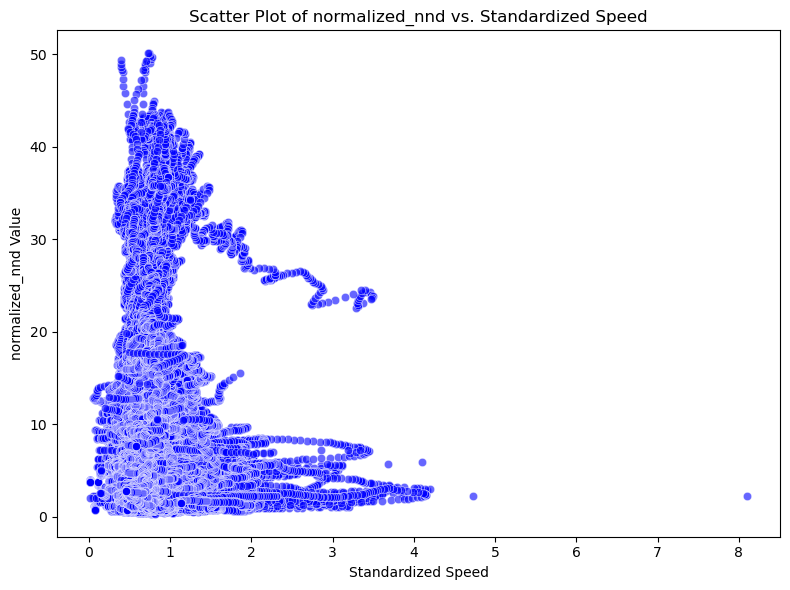

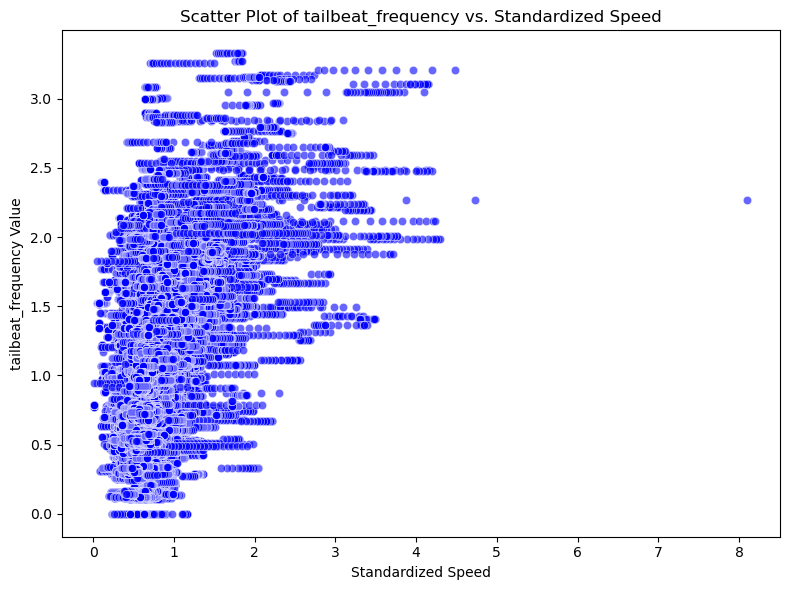

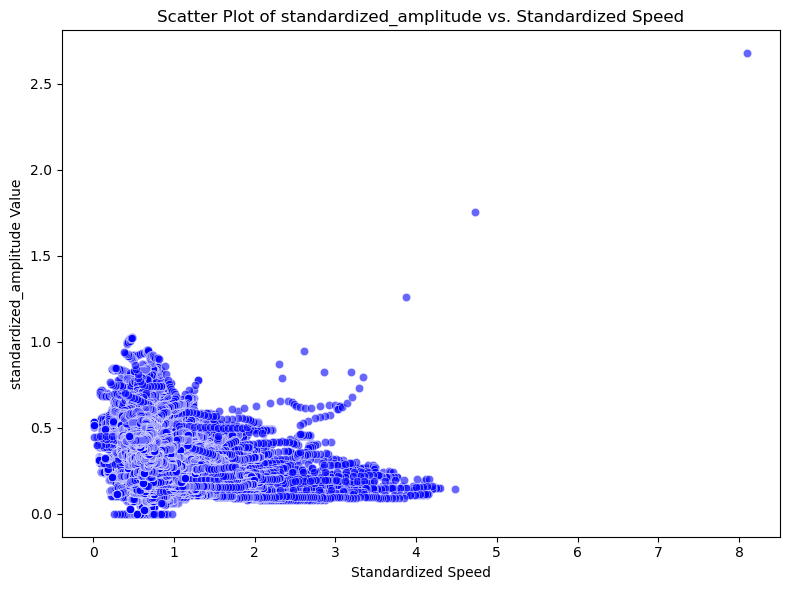

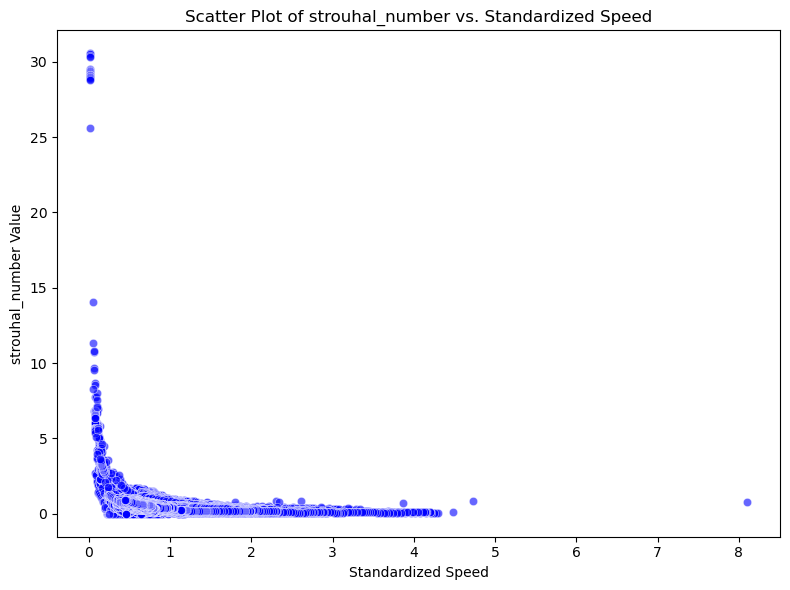

In [46]:
# Define the list of metrics you want to plot
metrics = ['normalized_nnd', 'tailbeat_frequency', 
           'standardized_amplitude', 'strouhal_number']

# Create separate scatter plots for each metric vs. standardized_speed
for metric in metrics:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df, x='standardized_speed', y=metric, alpha=0.6, color='b')
    
    # Set labels and title
    plt.xlabel('Standardized Speed')
    plt.ylabel(f'{metric} Value')
    plt.title(f'Scatter Plot of {metric} vs. Standardized Speed')
    
    # Display the plot
    plt.tight_layout()
    plt.show()

### Carangid boxplots

C:\Users\sophi\miniforge3\envs\data_analysis\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\sophi\miniforge3\envs\data_analysis\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\sophi\miniforge3\envs\data_analysis\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\sophi\miniforge3\envs\data_analysis\Lib\site-packages\seaborn\axisgrid.py:85

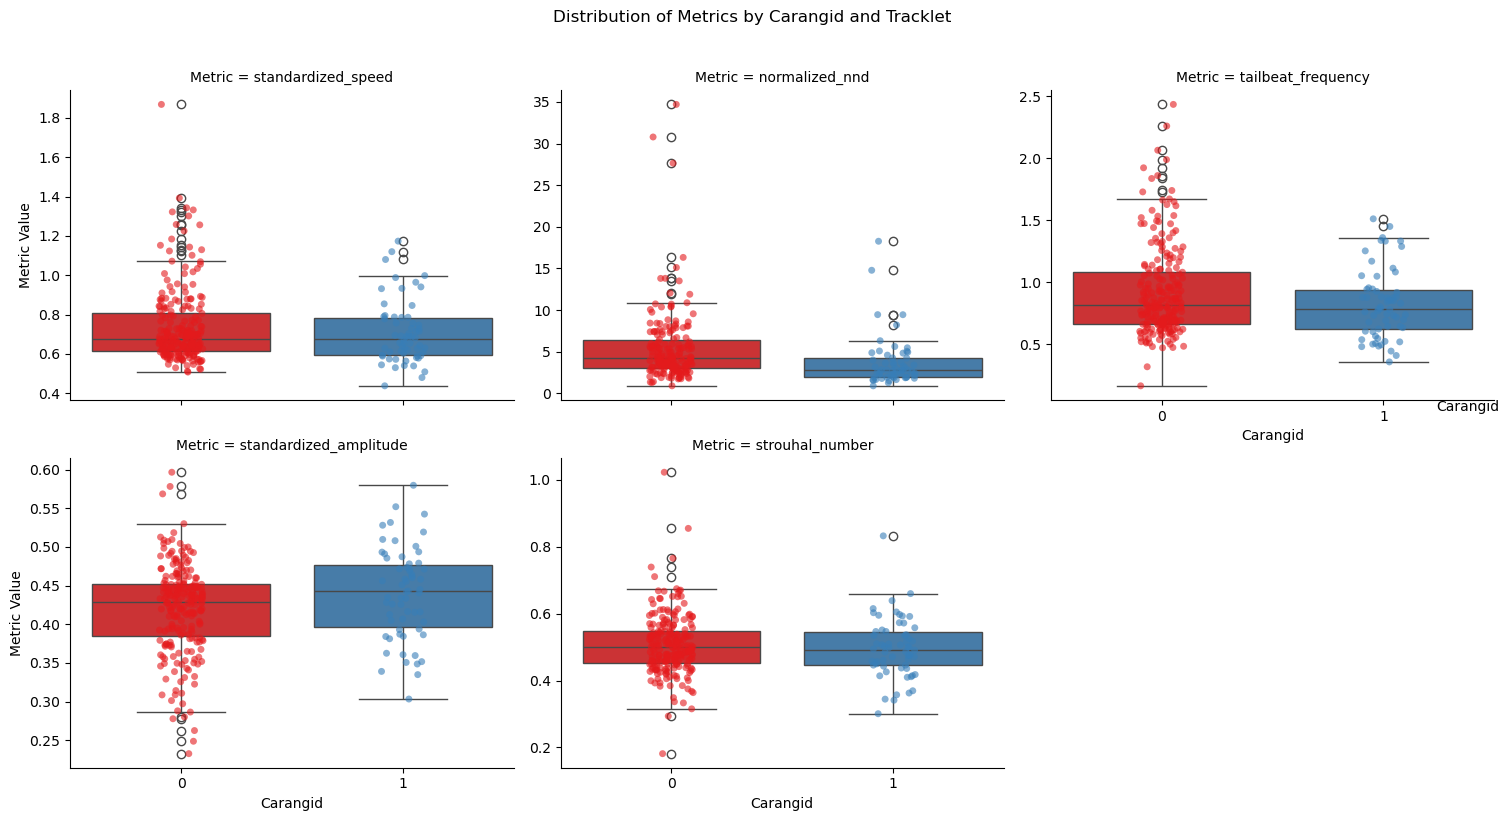

In [63]:
# Define the list of metrics
metrics = ['standardized_speed', 'normalized_nnd', 'tailbeat_frequency', 
           'standardized_amplitude', 'strouhal_number']

# Function to calculate tracklet averages for the metrics
def calculate_tracklet_averages(data, metrics):
    averages = []
    
    for (trial, tracklet, carangid), tracklet_data in data.groupby(['Trial', 'tracklet', 'carangids']):
        avg_values = {metric: tracklet_data[metric].mean() for metric in metrics}  # Compute mean for metrics
        avg_values['Trial'] = trial  # Include trial info
        avg_values['Tracklet'] = tracklet  # Include tracklet info
        avg_values['Carangid'] = carangid  # Include carangid info
        averages.append(avg_values)  
    
    return pd.DataFrame(averages)

# Calculate the averages for the metrics at the tracklet level
avg_df = calculate_tracklet_averages(df, metrics)

# Ensure 'Carangid' is treated as a categorical variable
avg_df['Carangid'] = avg_df['Carangid'].astype('category')

# ✅ Apply filtering: Only keep values < 2 for the specified metrics
avg_df.loc[avg_df['strouhal_number'] >= 2, 'strouhal_number'] = None

# Drop NaN values to avoid plotting empty values
avg_df_filtered = avg_df.dropna(subset=['strouhal_number'], how='all')

# Define the color palette for carangid (0: red, 1: blue)
palette = "Set1"

# Melt the DataFrame to make it easier to plot with FacetGrid
avg_df_melted = avg_df_filtered.melt(id_vars=['Trial', 'Tracklet', 'Carangid'],
                                     value_vars=metrics,
                                     var_name='Metric',
                                     value_name='Value')

# Create a FacetGrid: one plot per metric
g = sns.FacetGrid(avg_df_melted, col='Metric', col_wrap=3, height=4, aspect=1.2, sharey=False)

# Map a boxplot onto each facet (for each metric)
g.map_dataframe(sns.boxplot, x='Carangid', y='Value', palette=palette)

# Overlay strip plot for data points on top of the boxplot
g.map_dataframe(sns.stripplot, x="Carangid", y="Value", palette=palette, marker="o", alpha=0.6, jitter=True)

# Adjust labels, legend, and overall title
g.set_axis_labels("Carangid", "Metric Value")
g.fig.suptitle('Distribution of Metrics by Carangid and Tracklet', y=1.02)

# Add a legend
g.add_legend(title='Carangid')

# Save and show the plot
plt.tight_layout()
plt.savefig(f'{figures_path}metrics_carangid_tracklet_facetgrid.png')
plt.show()


In [29]:
import pandas as pd
from scipy.stats import ttest_ind, mannwhitneyu, shapiro

# Define the list of metrics
metrics = ['standardized_speed', 'normalized_nnd', 'tailbeat_frequency', 
           'standardized_amplitude', 'strouhal_number']

# Function to calculate tracklet averages for the metrics
def calculate_tracklet_averages(data, metrics):
    averages = []
    
    for (trial, tracklet, carangid), tracklet_data in data.groupby(['Trial', 'tracklet', 'carangids']):
        avg_values = {metric: tracklet_data[metric].mean() for metric in metrics}  # Compute mean for metrics
        avg_values['Trial'] = trial  # Include trial info
        avg_values['Tracklet'] = tracklet  # Include tracklet info
        avg_values['Carangid'] = carangid  # Include carangid info
        averages.append(avg_values)  
    
    return pd.DataFrame(averages)

# Calculate the averages for the metrics at the tracklet level
avg_df = calculate_tracklet_averages(df, metrics)

# Ensure 'Carangid' is treated as a categorical variable
avg_df['Carangid'] = avg_df['Carangid'].astype('category')

# ✅ Apply filtering: Only keep values < 2 for the specified metrics
avg_df.loc[avg_df['strouhal_number'] >= 2, 'strouhal_number'] = None

# Drop NaN values to avoid issues
avg_df_filtered = avg_df.dropna(subset=['strouhal_number'], how='all')

# Function to perform both tests
def perform_tests(df, metric):
    """Runs t-test and Mann-Whitney U test on a given metric."""
    group_0 = df[df["Carangid"] == 0][metric].dropna()
    group_1 = df[df["Carangid"] == 1][metric].dropna()
    
    if len(group_0) > 2 and len(group_1) > 2:  # Ensure enough data points
        # Check normality (Shapiro-Wilk test)
        normal_0 = shapiro(group_0).pvalue > 0.05
        normal_1 = shapiro(group_1).pvalue > 0.05
        normal = normal_0 and normal_1
        
        # Perform t-test if both groups are normal
        if normal:
            t_stat, t_p = ttest_ind(group_0, group_1, equal_var=False)
        else:
            t_stat, t_p = None, None  # Skip t-test if data isn't normal
        
        # Always perform Mann-Whitney U test
        u_stat, u_p = mannwhitneyu(group_0, group_1, alternative="two-sided")
        
        return {
            "Metric": metric,
            "Normality (Group 0)": normal_0,
            "Normality (Group 1)": normal_1,
            "Used t-test": normal,  # If true, t-test was performed
            "t-test p-value": t_p,
            "Mann-Whitney p-value": u_p
        }
    else:
        return {"Metric": metric, "Error": "Not enough data"}

# Run the tests for all metrics
results = [perform_tests(avg_df_filtered, metric) for metric in metrics]

# Convert results to a DataFrame for display
results_df = pd.DataFrame(results)
print(results_df)


                   Metric  Normality (Group 0)  Normality (Group 1)  \
0      standardized_speed                False                False   
1          normalized_nnd                False                False   
2      tailbeat_frequency                False                False   
3  standardized_amplitude                False                 True   
4         strouhal_number                False                False   

   Used t-test t-test p-value  Mann-Whitney p-value  
0        False           None              0.335116  
1        False           None              0.000011  
2        False           None              0.120232  
3        False           None              0.033183  
4        False           None              0.414286  


C:\Users\sophi\miniforge3\envs\data_analysis\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\sophi\miniforge3\envs\data_analysis\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\sophi\miniforge3\envs\data_analysis\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
C:\Users\sophi\miniforge3\envs\data_analysis\Lib\site-packages\seaborn\axisgrid.py:85

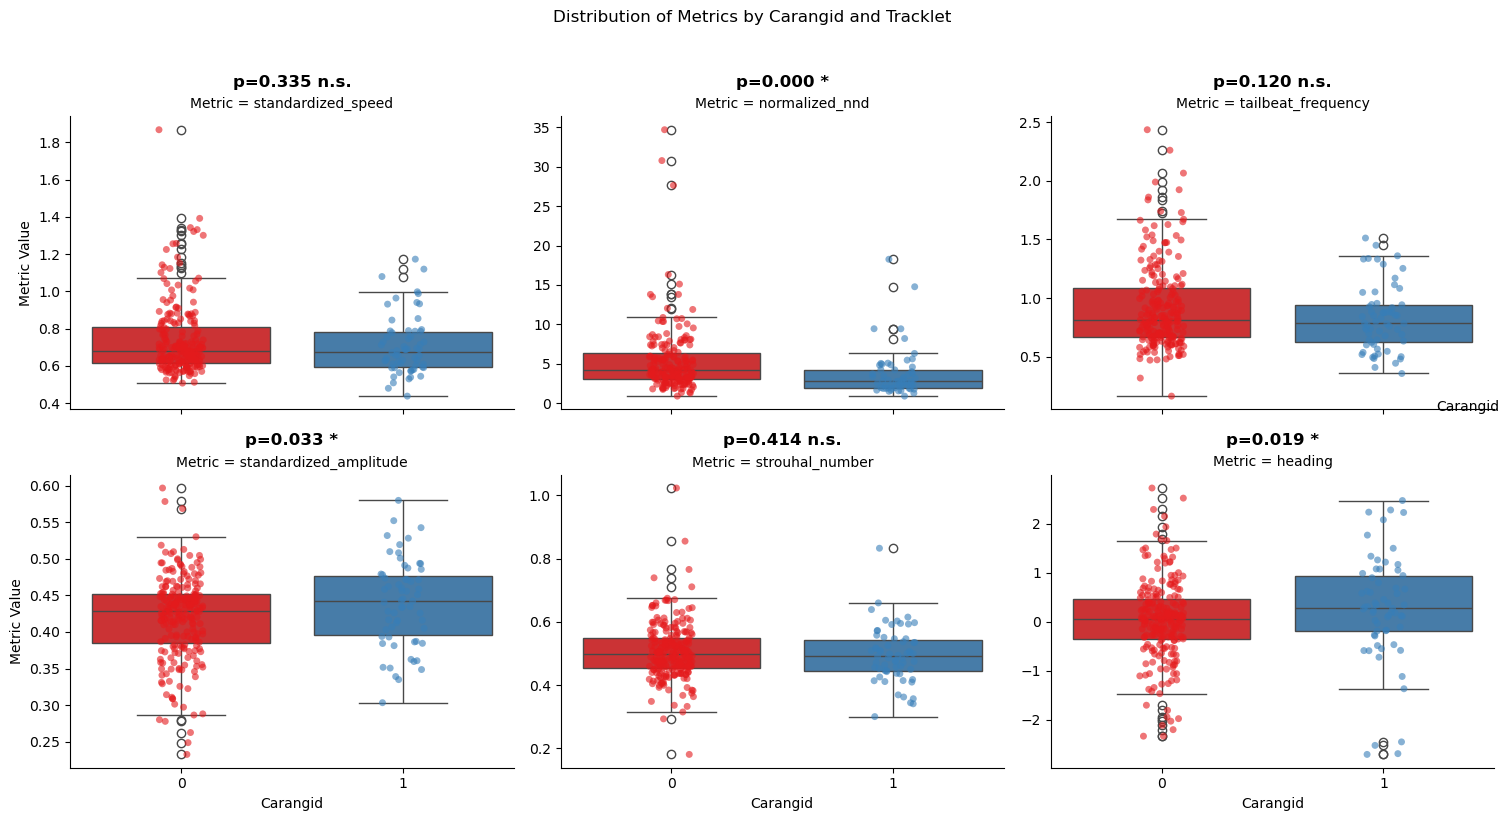

In [62]:
# Define the list of metrics
metrics = ['standardized_speed', 'normalized_nnd', 'tailbeat_frequency', 
           'standardized_amplitude', 'strouhal_number']

# Function to calculate tracklet averages for the metrics
def calculate_tracklet_averages(data, metrics):
    averages = []
    
    for (trial, tracklet, carangid), tracklet_data in data.groupby(['Trial', 'tracklet', 'carangids']):
        avg_values = {metric: tracklet_data[metric].mean() for metric in metrics}  # Compute mean for metrics
        avg_values['Trial'] = trial  # Include trial info
        avg_values['Tracklet'] = tracklet  # Include tracklet info
        avg_values['Carangid'] = carangid  # Include carangid info
        averages.append(avg_values)  
    
    return pd.DataFrame(averages)

# Calculate the averages for the metrics at the tracklet level
avg_df = calculate_tracklet_averages(df, metrics)

# Ensure 'Carangid' is treated as a categorical variable
avg_df['Carangid'] = avg_df['Carangid'].astype('category')

# ✅ Apply filtering: Only keep values < 2 for the specified metrics
avg_df.loc[avg_df['strouhal_number'] >= 2, 'strouhal_number'] = None

# Drop NaN values to avoid plotting empty values
avg_df_filtered = avg_df.dropna(subset=['strouhal_number'], how='all')

# Melt the DataFrame to make it easier to plot with FacetGrid
avg_df_melted = avg_df_filtered.melt(id_vars=['Trial', 'Tracklet', 'Carangid'],
                                     value_vars=metrics,
                                     var_name='Metric',
                                     value_name='Value')

# Define function to calculate p-values
def calculate_p_values(df, metric):
    """Performs t-test or Mann-Whitney test depending on normality."""
    group_0 = df[df["Carangid"] == 0][metric].dropna()
    group_1 = df[df["Carangid"] == 1][metric].dropna()

    if len(group_0) > 2 and len(group_1) > 2:  # Ensure enough data points
        _, p_value = mannwhitneyu(group_0, group_1, alternative="two-sided")  # Mann-Whitney U test
        return p_value
    else:
        return None  # Not enough data to test

# Create a FacetGrid: one plot per metric
g = sns.FacetGrid(avg_df_melted, col='Metric', col_wrap=3, height=4, aspect=1.2, sharey=False)

# Map a boxplot onto each facet (for each metric)
g.map_dataframe(sns.boxplot, x='Carangid', y='Value', palette="Set1")

# Overlay strip plot for data points on top of the boxplot
g.map_dataframe(sns.stripplot, x="Carangid", y="Value", palette="Set1", marker="o", alpha=0.6, jitter=True)

# Add p-values to the plots
for ax, metric in zip(g.axes.flat, metrics):
    p_val = calculate_p_values(avg_df_filtered, metric)
    if p_val is not None:
        sig = 'n.s.' if p_val >= 0.05 else '*' if p_val < 0.05 else '**' if p_val < 0.01 else '***'
        ax.annotate(f'p={p_val:.3f} {sig}', xy=(0.5, 1.1), xycoords='axes fraction',
                    ha='center', fontsize=12, fontweight='bold', color='black')

# Adjust labels, legend, and overall title
g.set_axis_labels("Carangid", "Metric Value")
g.fig.suptitle('Distribution of Metrics by Carangid and Tracklet', y=1.02)

# Add a legend
g.add_legend(title='Carangid')

# Save and show the plot
plt.tight_layout()
#plt.savefig(f'{figures_path}metrics_carangid_tracklet_facetgrid.png')
plt.show()

In [ ]:
sns.boxplot(x='unique_id_count',y='normalized_nnd',data = nndID, palette='Set1')
# Overlay strip plot for data points with the same palette
sns.stripplot(x="unique_id_count", y='normalized_nnd', data=nndID, palette='Set1', marker="o", alpha=0.6, jitter=True)
plt.savefig(figures_path + 'nndcountboxplot.png')

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate averages for multiple metrics with filtering
def calculate_segment_averages(data, metrics, min_count=1):
    averages = []
    for trial, trial_data in data.groupby('Trial'):
        for id_, id_data in trial_data.groupby('ID'):
            for segment, segment_data in id_data.groupby('segment'):  # Group by 'segment'
                if len(segment_data) >= min_count:  # Filter by minimum count
                    avg_values = {metric: segment_data[metric].mean() for metric in metrics}
                    avg_values['Trial'] = trial  # Add Trial information
                    avg_values['Carangid'] = segment_data['carangids'].iloc[0]  # Add carangid info
                    averages.append(avg_values)  # Append average values for all metrics
    return pd.DataFrame(averages)

# Metrics to plot
metrics = ['normalized_nnd']

# Calculate the averages for the metrics
avg_df = calculate_segment_averages(subset, metrics)

# Ensure 'Carangid' is treated as a categorical variable
avg_df['Carangid'] = avg_df['Carangid'].astype('category')

# Define color palette for carangid (0: red, 1: blue) with string keys to match the data
palette="Set1"

# Create plots for each metric
for metric in metrics:
    plt.figure(figsize=(12, 8))

    # Box plot for the current metric, with x as 'Carangid' and the specified color palette
    sns.boxplot(x="Carangid", y=metric, data=avg_df, palette=palette)

    # Overlay strip plot for data points with the same color palette
    sns.stripplot(
        x="Carangid", y=metric, data=avg_df, palette=palette, marker="o", alpha=0.6, jitter=True
    )

    # Add legend using Carangid values (0: red, 1: blue)
    handles = [
        plt.Line2D([0], [0], marker='o', color='red', linestyle='', markersize=10, label='Carangid 0'),
        plt.Line2D([0], [0], marker='o', color='blue', linestyle='', markersize=10, label='Carangid 1')
    ]
    plt.legend(handles=handles, title='Carangid', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Title and labels
    plt.title(f'{metric.replace("_", " ").title()} Distribution by Carangid with Data Points', fontsize=16)
    plt.xlabel("Carangid", fontsize=14)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=14)

    # Adjust layout for better readability
    plt.tight_layout()
    plt.savefig(figures_path + 'nndcarangidsboxplot.png')
    plt.show()


### Transitions

#### Transition 0->1

In [65]:
# ------------------------------------------------
# time_range defines the number of frames before and after the transition.
# ------------------------------------------------
time_range = 300

# List to store each transition window DataFrame
transition_windows = []

# Iterate over each trial.
for trial, trial_data in df.groupby('Trial'):
    # For each trial, first identify all transition events (for each individual).
    # We’ll store each event as a tuple: (center, source_id)
    trial_transitions = []
    
    for id_val, id_data in trial_data.groupby('ID'):
        # Ensure the data are sorted by the existing 'frame' column.
        id_data_sorted = id_data.sort_values('frame').reset_index(drop=True)
        # Compute the difference in carangids.
        diff_vals = id_data_sorted['carangids'].diff()
        # Find positions where the difference equals 1.
        trans_positions = diff_vals[diff_vals == 1].index.tolist()
        
        for pos in trans_positions:
            # Only consider events where the individual has at least time_range frames
            # before and after the event.
            if pos >= time_range and pos + time_range < len(id_data_sorted):
                center = id_data_sorted.loc[pos, 'frame']
                trial_transitions.append((center, id_val))
    
    # For each transition event detected in this trial, extract the corresponding window
    # for every individual in the trial.
    for center, source_id in trial_transitions:
        start_frame = center - time_range
        end_frame = center + time_range
        
        # Define the complete range of relative frames we expect: from -time_range to +time_range.
        rel_index = list(range(-time_range, time_range + 1))
        
        # For every individual in the trial, extract the window.
        for id_val, id_data in trial_data.groupby('ID'):
            # Subset the data for frames within the window.
            subset = id_data[(id_data['frame'] >= start_frame) & (id_data['frame'] <= end_frame)].copy()
            # Compute the relative frame for each row.
            subset['relative_frame'] = subset['frame'] - center
            
            # Reindex on the relative_frame so that the complete window is present.
            # Any missing frames will be filled with NaN.
            subset = subset.set_index('relative_frame').reindex(rel_index)
            
            # Add meta-information about the trial and transition.
            subset['Trial'] = trial
            subset['transition_center'] = center
            subset['source_id'] = source_id
            subset['ID'] = id_val
            
            # Reset index so that relative_frame is a column.
            subset = subset.reset_index()
            
            # Append this window DataFrame to our list.
            transition_windows.append(subset)

# Combine all the individual transition windows into one DataFrame.
transitions_df = pd.concat(transition_windows, ignore_index=True)

# transitions_df now contains, for each trial and each detected transition event,
# a complete window (from -time_range to +time_range relative to the event) for every ID.
# Missing frames (if an individual doesn't have enough frames) are filled with NaN.

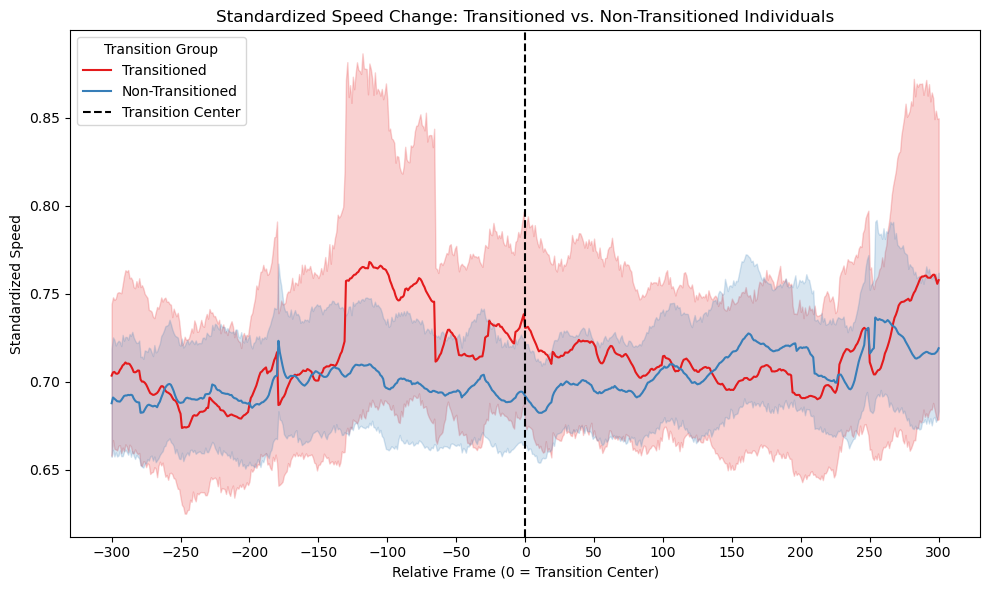

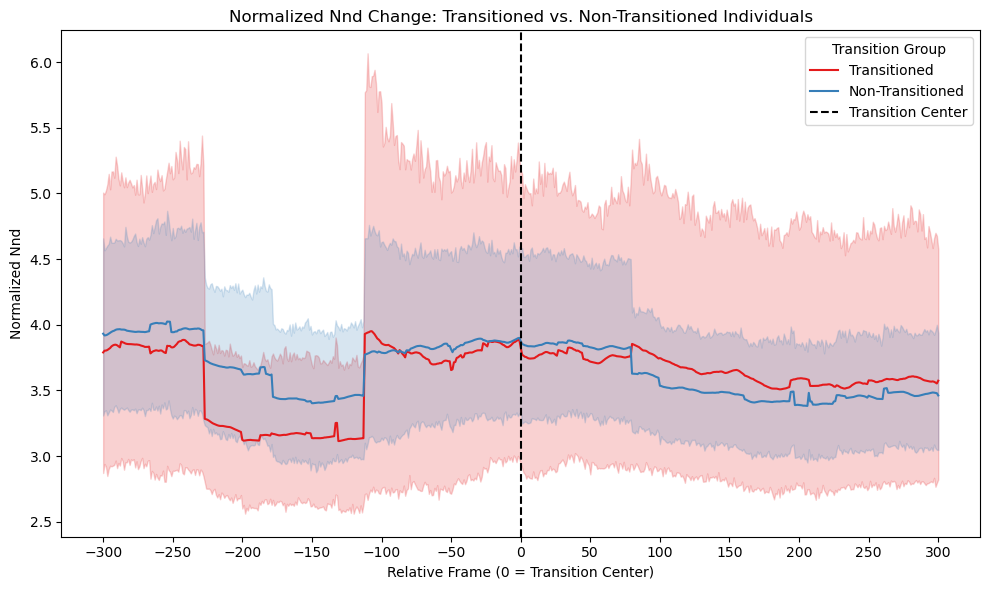

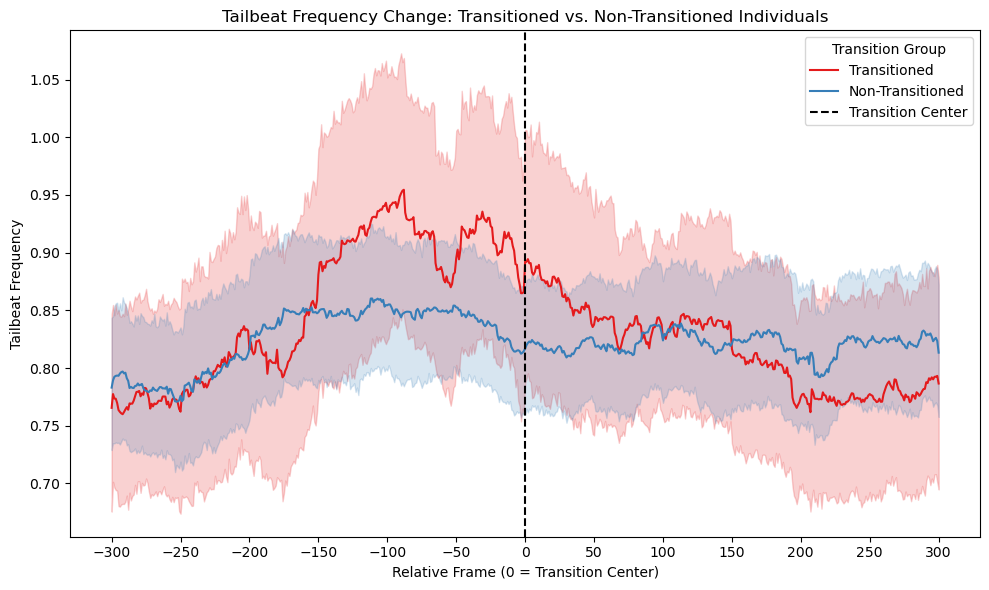

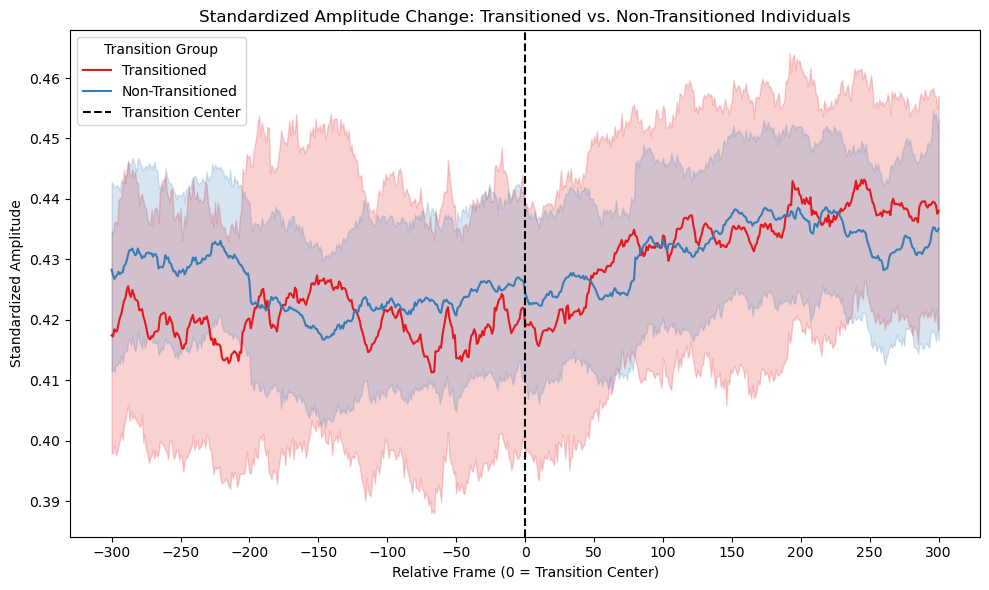

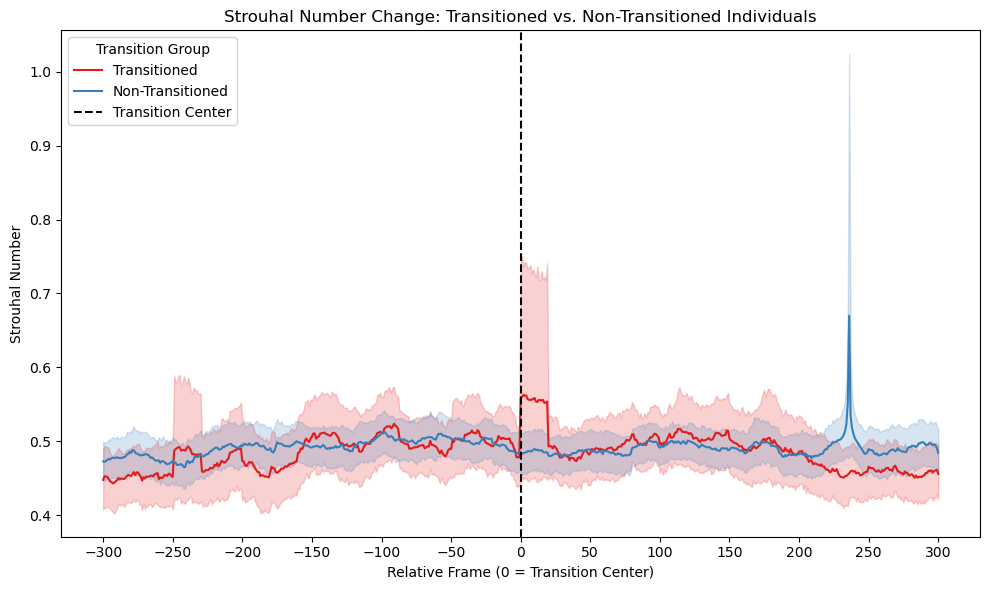

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a flag: True if the individual's ID equals the source_id for that transition.
transitions_df['transitioned'] = transitions_df['ID'] == transitions_df['source_id']

# Optionally, create a categorical label for plotting.
transitions_df['transition_group'] = transitions_df['transitioned'].map({True: 'Transitioned', False: 'Non-Transitioned'})

# List of metrics to plot
metrics = ['standardized_speed', 'normalized_nnd', 'tailbeat_frequency', 
           'standardized_amplitude', 'strouhal_number']

# Create FacetGrid: one plot per metric, no separate columns for transition groups
for metric in metrics:
    plt.figure(figsize=(10, 6))
    
    # Create the lineplot for Transitioned and Non-Transitioned individuals in the same plot
    sns.lineplot(data=transitions_df, x='relative_frame', y=metric, hue='transition_group', palette='Set1')
    
    # Add a vertical dashed line at 0 (the transition center)
    plt.axvline(0, color='black', linestyle='--', label='Transition Center')
    
    # Label and title adjustments
    plt.xlabel("Relative Frame (0 = Transition Center)")
    plt.ylabel(metric.replace("_", " ").title())  # Format metric name for readability
    plt.title(f"{metric.replace('_', ' ').title()} Change: Transitioned vs. Non-Transitioned Individuals")
    plt.legend(title='Transition Group')
    min_frame = transitions_df['relative_frame'].min()
    max_frame = transitions_df['relative_frame'].max()
    plt.xticks(range(min_frame - (min_frame % 50), max_frame + 1, 50))
    
    # Adjust layout for better readability
    plt.tight_layout()

    # Save the plot to a file
    plt.savefig(f'{figures_path}metrics_transition_facetgrid.png')
    
    # Show the plot
    plt.show()


#### Transition 1->0

In [70]:
# ------------------------------------------------
# time_range defines the number of frames before and after the transition.
# ------------------------------------------------
time_range = 300

# List to store each transition window DataFrame
transition_windows = []

# Iterate over each trial.
for trial, trial_data in df.groupby('Trial'):
    # For each trial, first identify all transition events (for each individual).
    # We’ll store each event as a tuple: (center, source_id)
    trial_transitions = []
    
    for id_val, id_data in trial_data.groupby('ID'):
        # Ensure the data are sorted by the existing 'frame' column.
        id_data_sorted = id_data.sort_values('frame').reset_index(drop=True)
        # Compute the difference in carangids.
        diff_vals = id_data_sorted['carangids'].diff()
        # Find positions where the difference equals 1.
        trans_positions = diff_vals[diff_vals == -1].index.tolist()
        
        for pos in trans_positions:
            # Only consider events where the individual has at least time_range frames
            # before and after the event.
            if pos >= time_range and pos + time_range < len(id_data_sorted):
                center = id_data_sorted.loc[pos, 'frame']
                trial_transitions.append((center, id_val))
    
    # For each transition event detected in this trial, extract the corresponding window
    # for every individual in the trial.
    for center, source_id in trial_transitions:
        start_frame = center - time_range
        end_frame = center + time_range
        
        # Define the complete range of relative frames we expect: from -time_range to +time_range.
        rel_index = list(range(-time_range, time_range + 1))
        
        # For every individual in the trial, extract the window.
        for id_val, id_data in trial_data.groupby('ID'):
            # Subset the data for frames within the window.
            subset = id_data[(id_data['frame'] >= start_frame) & (id_data['frame'] <= end_frame)].copy()
            # Compute the relative frame for each row.
            subset['relative_frame'] = subset['frame'] - center
            
            # Reindex on the relative_frame so that the complete window is present.
            # Any missing frames will be filled with NaN.
            subset = subset.set_index('relative_frame').reindex(rel_index)
            
            # Add meta-information about the trial and transition.
            subset['Trial'] = trial
            subset['transition_center'] = center
            subset['source_id'] = source_id
            subset['ID'] = id_val
            
            # Reset index so that relative_frame is a column.
            subset = subset.reset_index()
            
            # Append this window DataFrame to our list.
            transition_windows.append(subset)

# Combine all the individual transition windows into one DataFrame.
leavingtransitions_df = pd.concat(transition_windows, ignore_index=True)

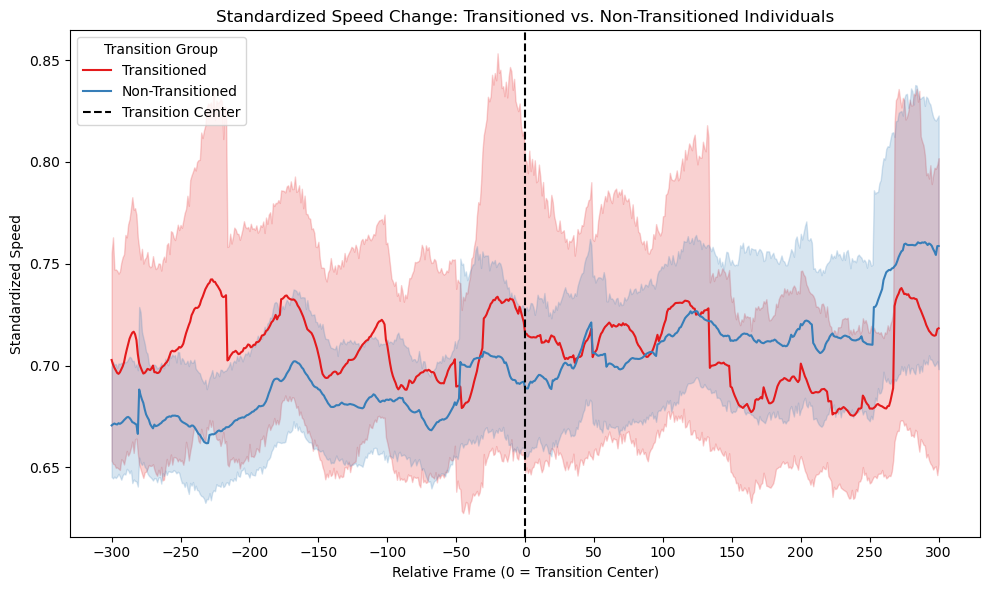

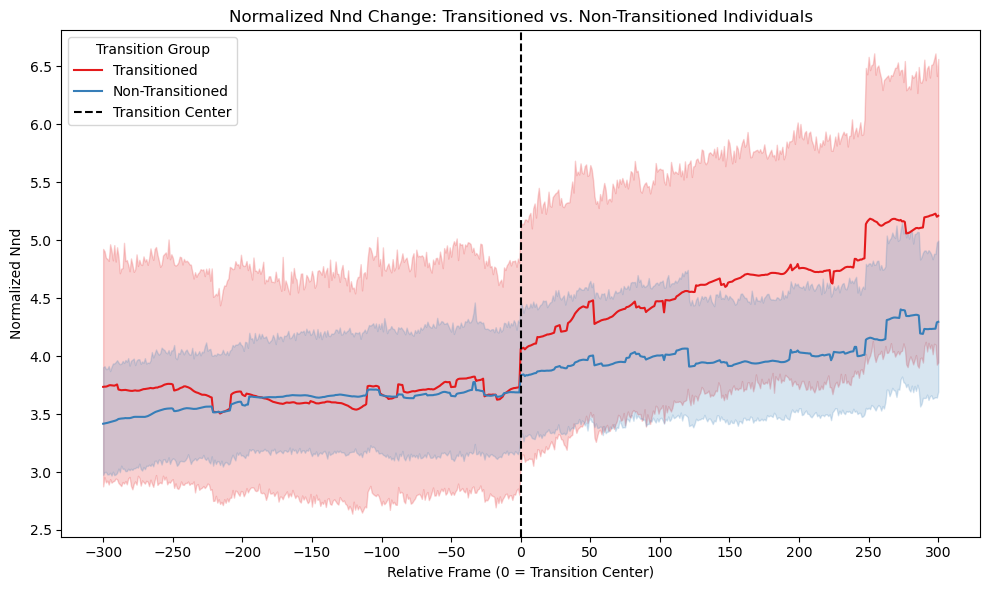

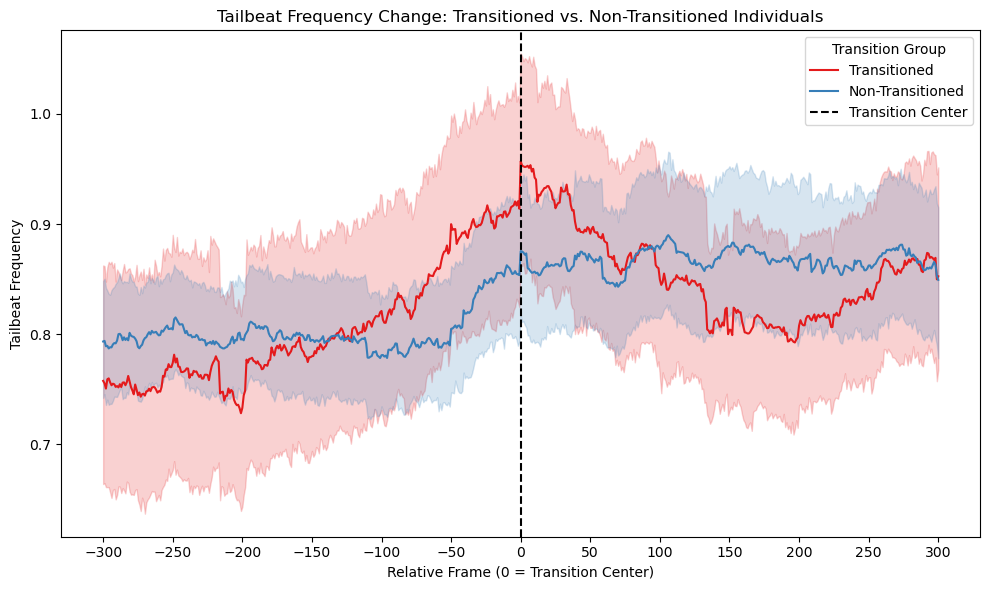

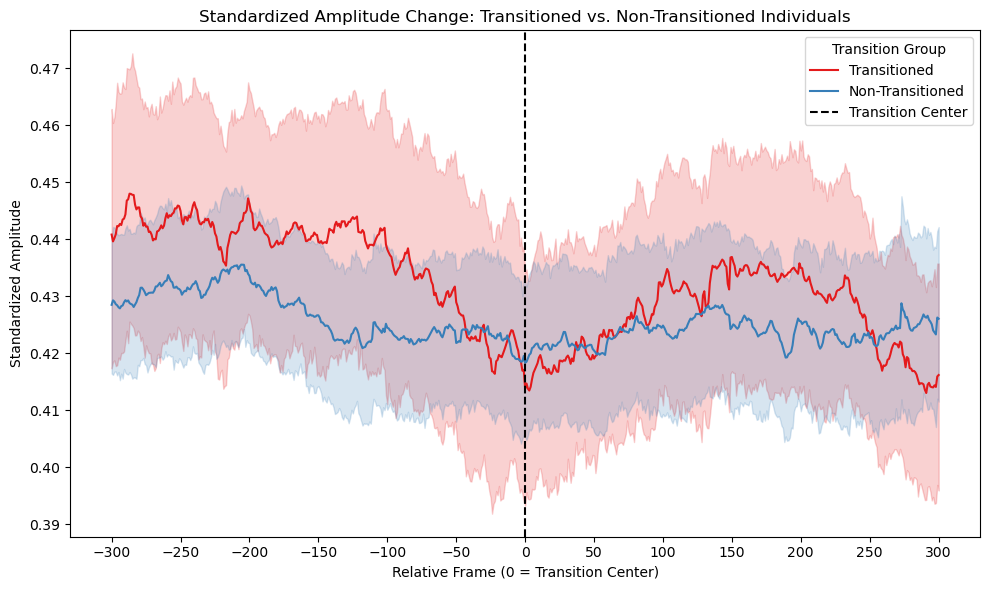

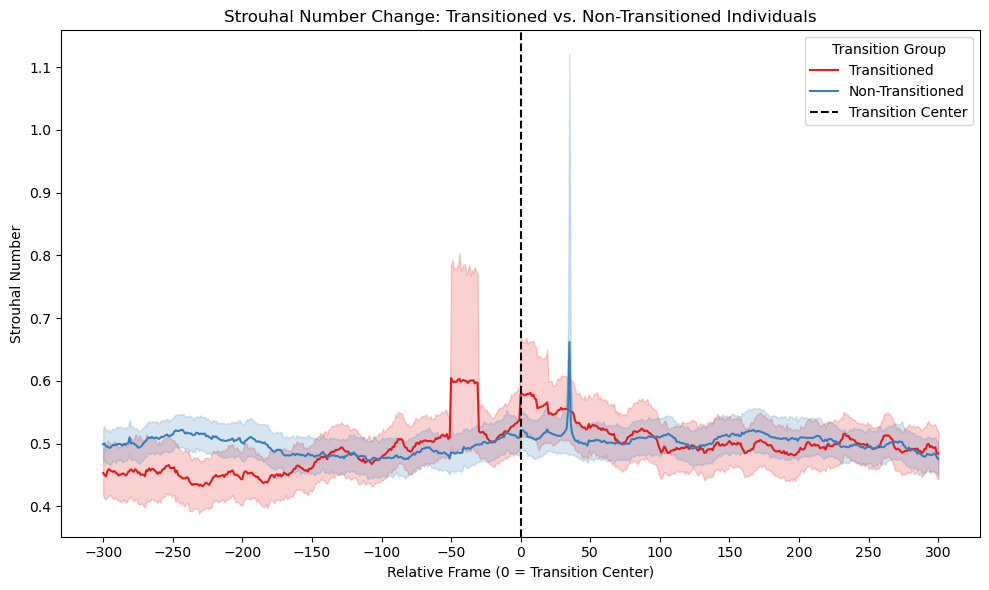

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a flag: True if the individual's ID equals the source_id for that transition.
leavingtransitions_df['transitioned'] = leavingtransitions_df['ID'] == leavingtransitions_df['source_id']

# Optionally, create a categorical label for plotting.
leavingtransitions_df['transition_group'] = leavingtransitions_df['transitioned'].map({True: 'Transitioned', False: 'Non-Transitioned'})

# List of metrics to plot
metrics = ['standardized_speed', 'normalized_nnd', 'tailbeat_frequency', 
           'standardized_amplitude', 'strouhal_number']

# Create FacetGrid: one plot per metric, no separate columns for transition groups
for metric in metrics:
    plt.figure(figsize=(10, 6))
    
    # Create the lineplot for Transitioned and Non-Transitioned individuals in the same plot
    sns.lineplot(data=leavingtransitions_df, x='relative_frame', y=metric, hue='transition_group', palette='Set1')
    
    # Add a vertical dashed line at 0 (the transition center)
    plt.axvline(0, color='black', linestyle='--', label='Transition Center')
    
    # Label and title adjustments
    plt.xlabel("Relative Frame (0 = Transition Center)")
    plt.ylabel(metric.replace("_", " ").title())  # Format metric name for readability
    plt.title(f"{metric.replace('_', ' ').title()} Change: Transitioned vs. Non-Transitioned Individuals")
    plt.legend(title='Transition Group')
    min_frame = leavingtransitions_df['relative_frame'].min()
    max_frame = leavingtransitions_df['relative_frame'].max()
    plt.xticks(range(min_frame - (min_frame % 50), max_frame + 1, 50))
    
    # Adjust layout for better readability
    plt.tight_layout()

    # Save the plot to a file
    plt.savefig(f'{figures_path}metrics_transitionleaving_facetgrid.png')
    
    # Show the plot
    plt.show()

### Kinematics

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate averages for multiple metrics with filtering
def calculate_segment_averages(data, metrics, min_count=100):
    averages = []
    for trial, trial_data in data.groupby('Trial'):
        for id_, id_data in trial_data.groupby('ID'):
            for segment, segment_data in id_data.groupby('segment'):  # Group by 'segment'
                if len(segment_data) >= min_count:  # Filter by minimum count
                    avg_values = {metric: segment_data[metric].mean() for metric in metrics}
                    avg_values['Trial'] = trial  # Add Trial information
                    avg_values['Carangid'] = segment_data['carangids'].iloc[0]  # Add carangid info
                    averages.append(avg_values)  # Append average values for all metrics
    return pd.DataFrame(averages)

# Metrics to plot
metrics = ['tailbeat_frequency', 'standardized_amplitude', 'strouhal_number']

# Calculate the averages for the metrics
avg_df = calculate_segment_averages(data2, metrics)

# Ensure 'Carangid' is treated as a categorical variable
avg_df['Carangid'] = avg_df['Carangid'].astype('category')

# Define color palette for carangid (0: red, 1: blue) with string keys to match the data
palette="Set1"

# Create plots for each metric
for metric in metrics:
    plt.figure(figsize=(12, 8))

    # Box plot for the current metric, with x as 'Carangid' and the specified color palette
    sns.boxplot(x="Carangid", y=metric, data=avg_df, palette=palette)

    # Overlay strip plot for data points with the same color palette
    sns.stripplot(
        x="Carangid", y=metric, data=avg_df, palette=palette, marker="o", alpha=0.6, jitter=True
    )

    # Add legend using Carangid values (0: red, 1: blue)
    handles = [
        plt.Line2D([0], [0], marker='o', color='red', linestyle='', markersize=10, label='Carangid 0'),
        plt.Line2D([0], [0], marker='o', color='blue', linestyle='', markersize=10, label='Carangid 1')
    ]
    plt.legend(handles=handles, title='Carangid', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Title and labels
    plt.title(f'{metric.replace("_", " ").title()} Distribution by Carangid with Data Points', fontsize=16)
    plt.xlabel("Carangid", fontsize=14)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=14)

    # Adjust layout for better readability
    plt.tight_layout()

    # Save each plot with a unique filename
    filename = f"{figures_path}carangidsboxplot{metric}.png"
    plt.savefig(filename)

    # Show the plot
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate averages for multiple metrics with filtering
def calculate_segment_averages(data, metrics, min_count=100):
    averages = []
    for trial, trial_data in data.groupby('Trial'):
        for id_, id_data in trial_data.groupby('ID'):
            for segment, segment_data in id_data.groupby('segment'):  # Group by 'segment'
                if len(segment_data) >= min_count:  # Filter by minimum count
                    avg_values = {metric: segment_data[metric].mean() for metric in metrics}
                    avg_values['Trial'] = trial  # Add Trial information
                    avg_values['Carangid'] = segment_data['carangids'].iloc[0]  # Add carangid info
                    averages.append(avg_values)  # Append average values for all metrics
    return pd.DataFrame(averages)

# Metrics to plot
metrics = ['heading','angular_velocity']

# Calculate the averages for the metrics
avg_df = calculate_segment_averages(data, metrics)

# Ensure 'Carangid' is treated as a categorical variable
avg_df['Carangid'] = avg_df['Carangid'].astype('category')

# Define color palette for carangid (0: red, 1: blue) with string keys to match the data
palette="Set1"

# Create plots for each metric
for metric in metrics:
    plt.figure(figsize=(12, 8))

    # Box plot for the current metric, with x as 'Carangid' and the specified color palette
    sns.boxplot(x="Carangid", y=metric, data=avg_df, palette=palette)

    # Overlay strip plot for data points with the same color palette
    sns.stripplot(
        x="Carangid", y=metric, data=avg_df, palette=palette, marker="o", alpha=0.6, jitter=True
    )

    # Add legend using Carangid values (0: red, 1: blue)
    handles = [
        plt.Line2D([0], [0], marker='o', color='red', linestyle='', markersize=10, label='Carangid 0'),
        plt.Line2D([0], [0], marker='o', color='blue', linestyle='', markersize=10, label='Carangid 1')
    ]
    plt.legend(handles=handles, title='Carangid', bbox_to_anchor=(1.05, 1), loc='upper left')

    # Title and labels
    plt.title(f'{metric.replace("_", " ").title()} Distribution by Carangid with Data Points', fontsize=16)
    plt.xlabel("Carangid", fontsize=14)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=14)

    # Adjust layout for better readability
    plt.tight_layout()
    plt.show()

In [ ]:
sns.boxplot(x='unique_id_count',y='tailbeat_frequency',data = tailbeatID, palette="Set1")
sns.stripplot(x="unique_id_count", y='tailbeat_frequency', data=tailbeatID, palette='Set1', marker="o", alpha=0.6, jitter=True)
plt.savefig(figures_path + 'tailbeatcountboxplot.png')
sns.boxplot(x='unique_id_count',y='standardized_amplitude',data = amplitudeID, palette="Set1")
sns.stripplot(x="unique_id_count", y='standardized_amplitude', data=amplitudeID, palette='Set1', marker="o", alpha=0.6, jitter=True)
plt.savefig(figures_path + 'amplitudecountboxplot.png')
sns.boxplot(x='unique_id_count',y='strouhal_number',data = strouhalID, palette="Set1")
sns.stripplot(x="unique_id_count", y='strouhal_number', data=strouhalID, palette='Set1', marker="o", alpha=0.6, jitter=True)
plt.savefig(figures_path + 'strouhalcountboxplot.png')